In [3]:
!pip install pandas matplotlib nibabel tensorflow scikit-learn

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.3 MB 820.2 kB/s eta 0:00:04
   --------- ------------------------------ 0.8/3.3 MB 1.0 MB/s eta 0:00:03
   --------- ------------------------------ 0.8/3.3 MB 1.0 MB/s eta 0:00:03
   ------------ --------------------------- 1.0/3.3 MB 886.6 kB/s eta 0:00:03
   --------------- ------------------------ 1.3/3.3 MB 832.9 kB/s eta 0:00:03
   --------------- ------------------------ 1.3/3.3 MB 832.9 kB/s eta 0:00:03
   ------------------- -------------------- 1.6/3.3 MB 855.5 kB/s eta 0:00:03
   ---------------------- ----------------- 1.8/3.3 MB 844.9 kB/s eta 0:00:02
   ---------------------- ----------------- 1.8/3.3 MB 844.9 kB/s eta 0:00:02
   -----------------------

🔍 Searching local drive: C:\NU\images\disc1\OAS1_0020_MR1 ...

✅ Found the skull-stripped file locally!
Exact Path: C:\NU\images\disc1\OAS1_0020_MR1\PROCESSED\MPRAGE\T88_111\OAS1_0020_MR1_mpr_n3_anon_111_t88_masked_gfc.hdr

❌ Error loading the image data: Invalid shape (1, 208, 176) for image data


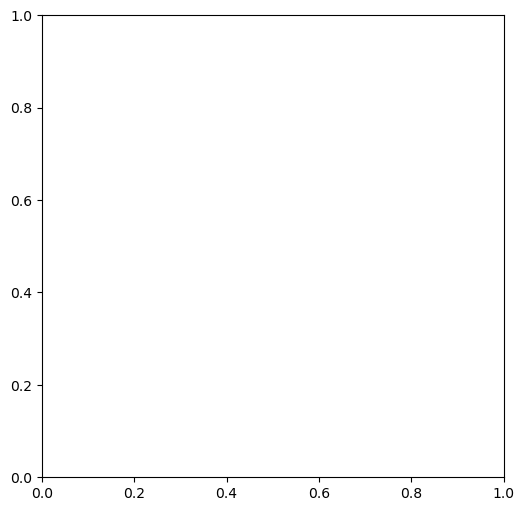

In [4]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# 1. The Windows Raw Path (The 'r' before the string prevents backslash errors)
patient_dir = r"C:\NU\images\disc1\OAS1_0020_MR1"

print(f"🔍 Searching local drive: {patient_dir} ...\n")

target_file_path = None

# 2. Local Bulletproof Search
for root, dirs, files in os.walk(patient_dir):
    for file in files:
        if file.endswith("masked_gfc.hdr"):
            target_file_path = os.path.join(root, file)
            break
    if target_file_path: 
        break

# 3. Load and Draw
if target_file_path:
    print(f"✅ Found the skull-stripped file locally!\nExact Path: {target_file_path}\n")
    try:
        mri_image = nib.load(target_file_path)
        image_data = mri_image.get_fdata()
        
        # Extract middle slice
        z_midpoint = image_data.shape[2] // 2
        middle_slice = image_data[:, :, z_midpoint]
        
        # Draw the brain
        plt.figure(figsize=(6, 6))
        plt.imshow(middle_slice.T, cmap='gray', origin='lower')
        plt.title("Perfect Skull-Stripped Brain\n(Loaded from Local C: Drive)")
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"❌ Error loading the image data: {e}")
else:
    print("❌ Could not find any masked_gfc.hdr file. Check your folder structure.")

In [9]:
import os
import pandas as pd
from PIL import Image

# 1. Paths 
csv_path = "data/CSV/Alzheimer_final.csv" 
local_drive_path = r"C:\NU\images"

df = pd.read_csv(csv_path)
image_paths = []
patients_found = 0

print("Initiating Broader Local Search for ANY Transverse GIF...")

# 2. Local Targeted Search Loop
for index, row in df.iterrows():
    p_id = str(row['ID'])
    found = False
    target_file_path = None
    
    for i in range(1, 13):
        disc_folder = f"disc{i}"
        patient_dir = os.path.join(local_drive_path, disc_folder, p_id)
        
        if os.path.exists(patient_dir):
            for root, dirs, files in os.walk(patient_dir):
                for file in files:
                    # THE FIX: Look for any file containing "masked_gfc_tra_"
                    if "masked_gfc_tra_" in file and file.endswith(".gif"):
                        target_file_path = os.path.join(root, file)
                        found = True
                        break # Stop searching once we find the slice
                if found:
                    break
        if found:
            break
            
    if found:
        image_paths.append(target_file_path)
        patients_found += 1
    else:
        image_paths.append(None)
        
# 3. Attach and Clean Up
df['Image_Path'] = image_paths
df_cnn = df.dropna(subset=['Image_Path']).reset_index(drop=True)

print(f"\nSearch Complete! Successfully linked GIFs for {len(df_cnn)} patients.")

# Save the updated dataset
df_cnn.to_csv("Alzheimer_Local_CNN_Ready.csv", index=False)
print("Saved mapping to 'Alzheimer_Local_CNN_Ready.csv'")

Initiating Broader Local Search for ANY Transverse GIF...

Search Complete! Successfully linked GIFs for 235 patients.
Saved mapping to 'Alzheimer_Local_CNN_Ready.csv'


In [26]:
import os

# Your new streamlined raw directory
raw_dir = r"C:\NU\images\OAS2_RAW"

print("--- 🧹 Running Directory Renamer ---")
renamed_count = 0

# Loop through everything inside the folder
for folder_name in os.listdir(raw_dir):
    old_path = os.path.join(raw_dir, folder_name)
    
    # Check if it's a folder and if it has the visit suffix
    if os.path.isdir(old_path) and "_MR" in folder_name:
        
        # Split at '_MR' and keep the base ID (e.g., 'OAS2_0001')
        new_name = folder_name.split('_MR')[0]
        new_path = os.path.join(raw_dir, new_name)
        
        try:
            # Physically rename the folder on the C: drive
            os.rename(old_path, new_path)
            renamed_count += 1
        except Exception as e:
            print(f"❌ Error renaming {folder_name}: {e}")

print(f"✅ Successfully renamed {renamed_count} folders to match the CSV IDs.")

--- 🧹 Running Directory Renamer ---
✅ Successfully renamed 2 folders to match the CSV IDs.


In [30]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from PIL import Image

# 1. Setup Folders
oas2_raw_path = r"C:\NU\images\OAS2_RAW"
output_dir = r"C:\NU\images\OAS2_Processed_Slices"
os.makedirs(output_dir, exist_ok=True)

# Load the data
df = pd.read_csv("data/CSV/Alzheimer_final.csv")
oas2_df = df[df['ID'].str.startswith('OAS2')].copy()

processed_paths = []
source_raw_paths = []

print("🚀 Starting Streamlined OASIS-2 Image Factory (Targeting RAW)...")

for index, row in oas2_df.iterrows():
    p_id = str(row['ID']) # e.g., "OAS2_0001"
    found = False
    
    # 2. THE FIX: Explicitly enter the "RAW" subfolder
    patient_raw_dir = os.path.join(oas2_raw_path, p_id, "RAW")
    
    if os.path.exists(patient_raw_dir):
        # Tunnel in to find the .hdr file
        for root, dirs, files in os.walk(patient_raw_dir):
            hdrs = [f for f in files if f.endswith('.hdr')]
            
            if hdrs:
                try:
                    target_path = os.path.join(root, hdrs[0])
                    
                    # Load 3D -> Slice to 2D
                    img_3d = nib.load(target_path)
                    data = img_3d.get_fdata()
                    
                    # Grab middle slice
                    slice_2d = data[:, :, data.shape[2] // 2]
                    
                    # Normalize pixels
                    slice_2d = ((slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8) * 255).astype(np.uint8)
                    
                    # Save as JPG
                    img_out = Image.fromarray(slice_2d.T)
                    out_path = os.path.join(output_dir, f"{p_id}.jpg")
                    img_out.save(out_path)
                    
                    processed_paths.append(out_path)
                    source_raw_paths.append(target_path) # Record the exact .hdr file used
                    
                    found = True
                    break 
                    
                except Exception as e:
                    continue
                    
            if found: break

    if not found:
        processed_paths.append(None)
        source_raw_paths.append(None)

# 3. Clean up and display
oas2_df['Image_Path'] = processed_paths
oas2_df['Source_Raw_Path'] = source_raw_paths
oas2_final = oas2_df.dropna(subset=['Image_Path']).reset_index(drop=True)

print(f"\n✅ Factory Complete! Created {len(oas2_final)} images from the RAW folders.")
display(oas2_final[['ID', 'Source_Raw_Path', 'Image_Path']].head())

🚀 Starting Streamlined OASIS-2 Image Factory (Targeting RAW)...

✅ Factory Complete! Created 0 images from the RAW folders.


,ID,Source_Raw_Path,Image_Path


In [29]:
oas2_df.head()

,ID,Age,Gender,Educ,MMSE,Target,eTIV,nWBV,Image_Path,Source_Raw_Path
861,OAS2_0001,1.366585,1,2.0,0.836511,0.0,7.000629,-3.023198,None,None
862,OAS2_0001,1.480482,1,2.0,1.159978,0.0,7.250253,-3.753068,None,None
863,OAS2_0002,-0.000182,1,1.0,0.405220,1.0,2.708890,-1.071412,None,None
864,OAS2_0002,0.113715,1,1.0,0.944333,1.0,3.534910,-2.184071,None,None
865,OAS2_0002,0.569304,1,1.0,0.297397,1.0,2.982065,-2.774313,None,None


In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. Load your perfect OASIS-1 Dataset
# (Make sure to use the CSV that successfully found the 235 patients)
df = pd.read_csv("Alzheimer_Local_CNN_Ready.csv")

# Ensure the target is a string for classification
df['Target'] = df['Target'].astype(str)

# 2. Train/Validation Split (80% Train, 20% Test)
# stratify ensures an equal mix of healthy/Alzheimer's in both sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Target'])

print(f"Original Training Patients: {len(train_df)}")
print(f"Validation Patients: {len(val_df)}\n")

# 3. THE MAGIC: Data Augmentation Generator
# This mathematically multiplies your data during training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to 0-1
    rotation_range=10,        # Slightly rotate the heads up to 10 degrees
    width_shift_range=0.05,   # Shift slightly left/right
    height_shift_range=0.05,  # Shift slightly up/down
    zoom_range=0.05,          # Slight zoom in/out
    fill_mode='nearest'       # Fill missing pixels with nearest color
)

# Validation data should NOT be augmented (it must be a pure test)
val_datagen = ImageDataGenerator(rescale=1./255)

# Physical constraints for the CNN
IMG_SIZE = (128, 128)
BATCH_SIZE = 16 # Smaller batches are better for smaller datasets

print("--- Loading Augmented Training Batches ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="Image_Path",
    y_col="Target",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\n--- Loading Validation Batches ---")
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="Image_Path",
    y_col="Target",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

🧠 Original Training Patients: 188
🧪 Validation Patients: 47

--- Loading Augmented Training Batches ---
Found 0 validated image filenames belonging to 0 classes.

--- Loading Validation Batches ---
Found 0 validated image filenames belonging to 0 classes.


c:\Users\zyado\anaconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:918: UserWarning: Found 188 invalid image filename(s) in x_col="Image_Path". These filename(s) will be ignored.
  warnings.warn(
c:\Users\zyado\anaconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:918: UserWarning: Found 47 invalid image filename(s) in x_col="Image_Path". These filename(s) will be ignored.
  warnings.warn(


In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("Building CNN Architecture...")

# 1. Define the Sequential Model
model = Sequential([
    # Block 1: The Initial Scan
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Deeper Feature Extraction
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Complex Pattern Recognition
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Transition from 2D images to a 1D array of numbers
    Flatten(),

    # Fully Connected Layer (The "Brain" of the network)
    Dense(128, activation='relu'),
    
    # Dropout to prevent memorization of the small dataset
    Dropout(0.5),

    # Output Layer: 1 Neuron (0 = Healthy, 1 = Alzheimer's)
    Dense(1, activation='sigmoid')
])

# 2. Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Compilation Complete. Model Summary:")
model.summary()

Building CNN Architecture...


c:\Users\zyado\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilation Complete. Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

--- Initializing Training Protocol ---
Commencing training for up to 30 Epochs...
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5673 - loss: 0.7487
Epoch 1: val_accuracy improved from None to 0.57447, saving model to best_alzheimer_cnn.keras

Epoch 1: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.5426 - loss: 0.7277 - val_accuracy: 0.5745 - val_loss: 0.6834
Epoch 2/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5461 - loss: 0.6835
Epoch 2: val_accuracy did not improve from 0.57447
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5426 - loss: 0.6912 - val_accuracy: 0.5745 - val_loss: 0.6907
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5849 - loss: 0.6892
Epoch 3: val_accuracy did not improve from 0.57447
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5745 - loss: 0.6870 - val_accuracy: 0.5745 - val_loss: 0.6822
Epoch 4/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accur

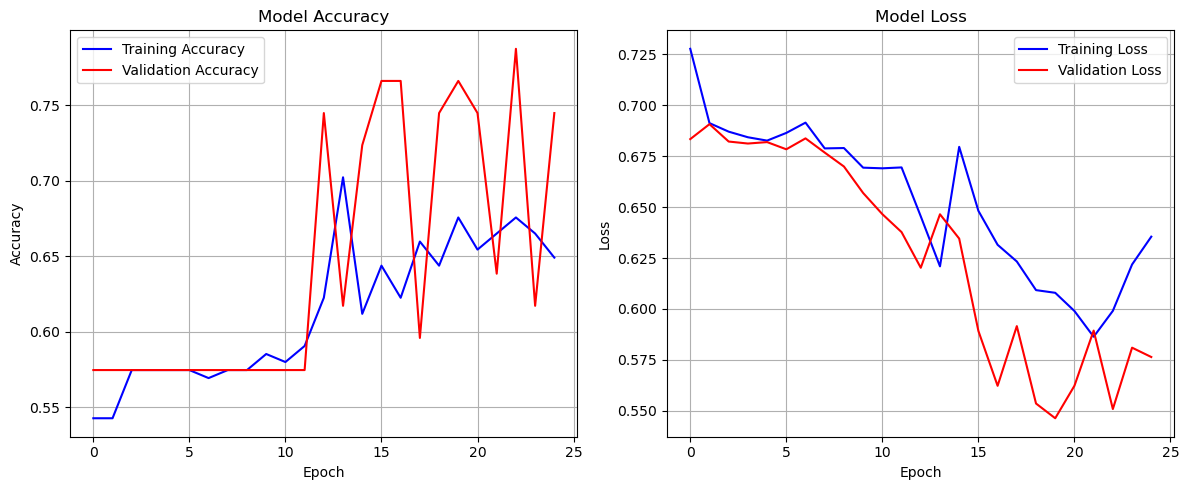

In [35]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("--- Initializing Training Protocol ---")

# 1. Define the Callbacks (The Safety Nets)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_alzheimer_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# 2. Execute the Training Loop
EPOCHS = 30 # Maximum number of rounds

print(f"Commencing training for up to {EPOCHS} Epochs...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

print("\n--- Training Complete ---")

# 3. Visualize the Learning Curve
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Generating Interactive Plotly Dashboard...")

# 1. Create a 1x2 subplot layout
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Model Accuracy', 'Model Loss')
)

# 2. Add Accuracy Traces (Left Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['accuracy'], 
        mode='lines', 
        name='Training Accuracy', 
        line=dict(color='blue')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_accuracy'], 
        mode='lines', 
        name='Validation Accuracy', 
        line=dict(color='red')
    ),
    row=1, col=1
)

# 3. Add Loss Traces (Right Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['loss'], 
        mode='lines', 
        name='Training Loss', 
        line=dict(color='blue', dash='dot') # Dashed line for distinction
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_loss'], 
        mode='lines', 
        name='Validation Loss', 
        line=dict(color='red', dash='dot')
    ),
    row=1, col=2
)

# 4. Professional Layout Formatting
fig.update_layout(
    title_text='CNN Training Performance Dashboard',
    title_x=0.5, # Center the title
    template='plotly_white',
    hovermode='x unified', # Shows all data points for an epoch on hover
    showlegend=True,
    height=500
)

# Set axes titles
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Accuracy', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=1, col=2)

# 5. Render the interactive plot
fig.show()

Generating Interactive Plotly Dashboard...


In [34]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. Load the OASIS-1 CSV
csv_path = "Alzheimer_Local_CNN_Ready.csv" 
df = pd.read_csv(csv_path)

# Ensure Target is a string for classification
df['Target'] = df['Target'].astype(str)

# 2. Train/Validation Split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Target'])

print(f"Original Training Patients: {len(train_df)}")
print(f"Validation Patients: {len(val_df)}\n")

# 3. Data Generators with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (128, 128)
BATCH_SIZE = 16 

print("--- Loading Training Batches ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="Image_Path",
    y_col="Target",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validate_filenames=False # OVERRIDE: Forces Keras to accept the .gif files
)

print("\n--- Loading Validation Batches ---")
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="Image_Path",
    y_col="Target",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validate_filenames=False # OVERRIDE
)

Original Training Patients: 188
Validation Patients: 47

--- Loading Training Batches ---
Found 188 non-validated image filenames belonging to 2 classes.

--- Loading Validation Batches ---
Found 47 non-validated image filenames belonging to 2 classes.


In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

print("Building Aggressively Regularized CNN...")

# 1. Define the Constrained Model
model = Sequential([
    # Block 1: Basic edges, heavy penalty for memorization
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 1), kernel_regularizer=l2(0.01)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2), # Randomly blind 20% of the scan

    # Block 2
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3), # Randomly blind 30% of the scan

    # Block 3
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4), # Randomly blind 40% of the scan

    Flatten(),

    # Shrink the "Brain" from 128 down to 32
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5), # Kill 50% of decision pathways

    Dense(1, activation='sigmoid')
])

# 2. Compile with a slightly slower learning rate
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0005) # Slower learning prevents jumping to memorization

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Building Aggressively Regularized CNN...


c:\Users\zyado\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       401,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,769 (1.62 MB)

 Trainable params: 424,769 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import plotly.graph_objects as go
from plotly.subplots import make_subplots


print("--- Initializing Training Protocol ---")

# 1. Define the Callbacks (The Safety Nets)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_alzheimer_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# 2. Execute the Training Loop
EPOCHS = 30 # Maximum number of rounds

print(f"Commencing training for up to {EPOCHS} Epochs...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

print("\n--- Training Complete ---")

print("Generating Interactive Plotly Dashboard...")

# 1. Create a 1x2 subplot layout
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Model Accuracy', 'Model Loss')
)

# 2. Add Accuracy Traces (Left Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['accuracy'], 
        mode='lines', 
        name='Training Accuracy', 
        line=dict(color='blue')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_accuracy'], 
        mode='lines', 
        name='Validation Accuracy', 
        line=dict(color='red')
    ),
    row=1, col=1
)

# 3. Add Loss Traces (Right Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['loss'], 
        mode='lines', 
        name='Training Loss', 
        line=dict(color='blue', dash='dot') # Dashed line for distinction
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_loss'], 
        mode='lines', 
        name='Validation Loss', 
        line=dict(color='red', dash='dot')
    ),
    row=1, col=2
)

# 4. Professional Layout Formatting
fig.update_layout(
    title_text='CNN Training Performance Dashboard',
    title_x=0.5, # Center the title
    template='plotly_white',
    hovermode='x unified', # Shows all data points for an epoch on hover
    showlegend=True,
    height=500
)

# Set axes titles
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Accuracy', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=1, col=2)

# 5. Render the interactive plot
fig.show()

--- Initializing Training Protocol ---
Commencing training for up to 30 Epochs...
Epoch 1/30
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5196 - loss: 1.9169
Epoch 1: val_accuracy improved from None to 0.57447, saving model to best_alzheimer_cnn.keras

Epoch 1: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5160 - loss: 1.8446 - val_accuracy: 0.5745 - val_loss: 1.6750
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5287 - loss: 1.6298
Epoch 2: val_accuracy did not improve from 0.57447
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5213 - loss: 1.5775 - val_accuracy: 0.5745 - val_loss: 1.4637
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5446 - loss: 1.4216
Epoch 3: val_accuracy did not improve from 0.57447
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5745 - loss: 1.3838 - val_accuracy: 0.5745 - val_loss: 1.3070
Epoch 4/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accura

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("Building Balanced CNN Architecture...")

model = Sequential([
    # Block 1: Allowed to learn freely (No L2 penalty)
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2), # Mild blinding

    # Block 2
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Block 3
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),

    # The "Brain"
    Dense(64, activation='relu'),
    Dropout(0.5), # Keep a strong block here before the final decision

    Dense(1, activation='sigmoid')
])

# Restore the standard learning rate so it has the energy to learn
optimizer = Adam(learning_rate=0.001) 

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Building Balanced CNN Architecture...


c:\Users\zyado\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,241 (3.15 MB)

 Trainable params: 826,241 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import plotly.graph_objects as go
from plotly.subplots import make_subplots


print("--- Initializing Training Protocol ---")

# 1. Define the Callbacks (The Safety Nets)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_alzheimer_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# 2. Execute the Training Loop
EPOCHS = 30 # Maximum number of rounds

print(f"Commencing training for up to {EPOCHS} Epochs...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

print("\n--- Training Complete ---")

print("Generating Interactive Plotly Dashboard...")

# 1. Create a 1x2 subplot layout
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Model Accuracy', 'Model Loss')
)

# 2. Add Accuracy Traces (Left Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['accuracy'], 
        mode='lines', 
        name='Training Accuracy', 
        line=dict(color='blue')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_accuracy'], 
        mode='lines', 
        name='Validation Accuracy', 
        line=dict(color='red')
    ),
    row=1, col=1
)

# 3. Add Loss Traces (Right Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['loss'], 
        mode='lines', 
        name='Training Loss', 
        line=dict(color='blue', dash='dot') # Dashed line for distinction
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_loss'], 
        mode='lines', 
        name='Validation Loss', 
        line=dict(color='red', dash='dot')
    ),
    row=1, col=2
)

# 4. Professional Layout Formatting
fig.update_layout(
    title_text='CNN Training Performance Dashboard',
    title_x=0.5, # Center the title
    template='plotly_white',
    hovermode='x unified', # Shows all data points for an epoch on hover
    showlegend=True,
    height=500
)

# Set axes titles
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Accuracy', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=1, col=2)

# 5. Render the interactive plot
fig.show()

--- Initializing Training Protocol ---
Commencing training for up to 30 Epochs...
Epoch 1/30
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4748 - loss: 0.7095
Epoch 1: val_accuracy improved from None to 0.57447, saving model to best_alzheimer_cnn.keras

Epoch 1: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4787 - loss: 0.7119 - val_accuracy: 0.5745 - val_loss: 0.6904
Epoch 2/30
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6500 - loss: 0.6733
Epoch 2: val_accuracy did not improve from 0.57447
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6064 - loss: 0.6802 - val_accuracy: 0.5745 - val_loss: 0.6876
Epoch 3/30
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6060 - loss: 0.6842
Epoch 3: val_accuracy did not improve from 0.57447
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5745 - loss: 0.6860 - val_accuracy: 0.5745 - val_loss: 0.6872
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accura

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. Load the CSV
csv_path = "Alzheimer_Local_CNN_Ready.csv" 
df = pd.read_csv(csv_path)
df['Target'] = df['Target'].astype(str)

# 2. Train/Validation Split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Target'])

# 3. GENTLER Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,        # Reduced from 10
    width_shift_range=0.02,  # Reduced from 0.05
    height_shift_range=0.02, # Reduced from 0.05
    zoom_range=0.02,         # Reduced from 0.05
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (128, 128)
BATCH_SIZE = 16 

print("--- Loading Batches ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col="Image_Path", y_col="Target",
    target_size=IMG_SIZE, color_mode="grayscale", class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=True, validate_filenames=False
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col="Image_Path", y_col="Target",
    target_size=IMG_SIZE, color_mode="grayscale", class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=False, validate_filenames=False
)

--- Loading Batches ---
Found 188 non-validated image filenames belonging to 2 classes.
Found 47 non-validated image filenames belonging to 2 classes.


In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

print("Building Batch-Normalized CNN Architecture...")

model = Sequential([
    # Block 1
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    BatchNormalization(), # <--- THE FIX
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2), 

    # Block 2
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(), # <--- THE FIX
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 3
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(), # <--- THE FIX
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Flatten(),

    Dense(64, activation='relu'),
    BatchNormalization(), # <--- THE FIX
    Dropout(0.5), 

    Dense(1, activation='sigmoid')
])

# We use a slightly faster learning rate now that Batch Norm keeps it stable
optimizer = Adam(learning_rate=0.001) 

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Building Batch-Normalized CNN Architecture...


c:\Users\zyado\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,945 (3.15 MB)

 Trainable params: 826,593 (3.15 MB)

 Non-trainable params: 352 (1.38 KB)

In [43]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import plotly.graph_objects as go
from plotly.subplots import make_subplots


print("--- Initializing Training Protocol ---")

# 1. Define the Callbacks (The Safety Nets)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_alzheimer_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# 2. Execute the Training Loop
EPOCHS = 30 # Maximum number of rounds

print(f"Commencing training for up to {EPOCHS} Epochs...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

print("\n--- Training Complete ---")

print("Generating Interactive Plotly Dashboard...")

# 1. Create a 1x2 subplot layout
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Model Accuracy', 'Model Loss')
)

# 2. Add Accuracy Traces (Left Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['accuracy'], 
        mode='lines', 
        name='Training Accuracy', 
        line=dict(color='blue')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_accuracy'], 
        mode='lines', 
        name='Validation Accuracy', 
        line=dict(color='red')
    ),
    row=1, col=1
)

# 3. Add Loss Traces (Right Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['loss'], 
        mode='lines', 
        name='Training Loss', 
        line=dict(color='blue', dash='dot') # Dashed line for distinction
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_loss'], 
        mode='lines', 
        name='Validation Loss', 
        line=dict(color='red', dash='dot')
    ),
    row=1, col=2
)

# 4. Professional Layout Formatting
fig.update_layout(
    title_text='CNN Training Performance Dashboard',
    title_x=0.5, # Center the title
    template='plotly_white',
    hovermode='x unified', # Shows all data points for an epoch on hover
    showlegend=True,
    height=500
)

# Set axes titles
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Accuracy', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=1, col=2)

# 5. Render the interactive plot
fig.show()

--- Initializing Training Protocol ---
Commencing training for up to 30 Epochs...
Epoch 1/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6228 - loss: 0.8613
Epoch 1: val_accuracy improved from None to 0.40426, saving model to best_alzheimer_cnn.keras

Epoch 1: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6223 - loss: 0.8876 - val_accuracy: 0.4043 - val_loss: 0.7004
Epoch 2/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6578 - loss: 0.7587
Epoch 2: val_accuracy improved from 0.40426 to 0.42553, saving model to best_alzheimer_cnn.keras

Epoch 2: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6383 - loss: 0.7782 - val_accuracy: 0.4255 - val_loss: 0.7593
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6173 - loss: 0.7660
Epoch 3: val_accuracy did not improve from 0.42553
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6223 - loss: 0.

In [44]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. Load the CSV
csv_path = "Alzheimer_Local_CNN_Ready.csv" 
df = pd.read_csv(csv_path)
df['Target'] = df['Target'].astype(str)

# 2. Train/Validation Split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Target'])

# 3. GENTLER Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,        
    width_shift_range=0.02,  
    height_shift_range=0.02, 
    zoom_range=0.02,         
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (128, 128)
BATCH_SIZE = 16 

print("--- Loading RGB Batches for Transfer Learning ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col="Image_Path", y_col="Target",
    target_size=IMG_SIZE, 
    color_mode="rgb", # <--- THE FIX: Switched to rgb
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=True, validate_filenames=False
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col="Image_Path", y_col="Target",
    target_size=IMG_SIZE, 
    color_mode="rgb", # <--- THE FIX: Switched to rgb
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False, validate_filenames=False
)

--- Loading RGB Batches for Transfer Learning ---
Found 188 non-validated image filenames belonging to 2 classes.
Found 47 non-validated image filenames belonging to 2 classes.


In [45]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

print("Downloading Pre-Trained VGG16 Brain...")

# 1. Download the Base Expert Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# 2. FREEZE the core so it doesn't forget how to see
base_model.trainable = False

# 3. Build our Custom Alzheimer's Head
x = base_model.output
x = GlobalAveragePooling2D()(x) # Condenses the expert features
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Keep a safety net
predictions = Dense(1, activation='sigmoid')(x)

# 4. Stitch them together
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning Model Ready!")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 47s 1us/step
Transfer Learning Model Ready!


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import plotly.graph_objects as go
from plotly.subplots import make_subplots


print("--- Initializing Training Protocol ---")

# 1. Define the Callbacks (The Safety Nets)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_alzheimer_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# 2. Execute the Training Loop
EPOCHS = 30 # Maximum number of rounds

print(f"Commencing training for up to {EPOCHS} Epochs...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

print("\n--- Training Complete ---")

print("Generating Interactive Plotly Dashboard...")

# 1. Create a 1x2 subplot layout
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Model Accuracy', 'Model Loss')
)

# 2. Add Accuracy Traces (Left Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['accuracy'], 
        mode='lines', 
        name='Training Accuracy', 
        line=dict(color='blue')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_accuracy'], 
        mode='lines', 
        name='Validation Accuracy', 
        line=dict(color='red')
    ),
    row=1, col=1
)

# 3. Add Loss Traces (Right Graph)
fig.add_trace(
    go.Scatter(
        y=history.history['loss'], 
        mode='lines', 
        name='Training Loss', 
        line=dict(color='blue', dash='dot') # Dashed line for distinction
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        y=history.history['val_loss'], 
        mode='lines', 
        name='Validation Loss', 
        line=dict(color='red', dash='dot')
    ),
    row=1, col=2
)

# 4. Professional Layout Formatting
fig.update_layout(
    title_text='CNN Training Performance Dashboard',
    title_x=0.5, # Center the title
    template='plotly_white',
    hovermode='x unified', # Shows all data points for an epoch on hover
    showlegend=True,
    height=500
)

# Set axes titles
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Accuracy', row=1, col=1)
fig.update_yaxes(title_text='Loss', row=1, col=2)

# 5. Render the interactive plot
fig.show()

--- Initializing Training Protocol ---
Commencing training for up to 30 Epochs...
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5747 - loss: 0.7036
Epoch 1: val_accuracy improved from None to 0.57447, saving model to best_alzheimer_cnn.keras

Epoch 1: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 303ms/step - accuracy: 0.5798 - loss: 0.7015 - val_accuracy: 0.5745 - val_loss: 0.7178
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.5916 - loss: 0.6808
Epoch 2: val_accuracy improved from 0.57447 to 0.63830, saving model to best_alzheimer_cnn.keras

Epoch 2: finished saving model to best_alzheimer_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step - accuracy: 0.5585 - loss: 0.6924 - val_accuracy: 0.6383 - val_loss: 0.6591
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5803 - loss: 0.6569
Epoch 3: val_accuracy did not improve from 0.63830
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.5904 - lo

In [55]:
import numpy as np
import random
from tensorflow.keras.preprocessing import image
import plotly.express as px
import plotly.graph_objects as go

print("--- Initializing AI Diagnostic System (Plotly Edition) ---")

# 1. Select a random patient from your validation dataframe
random_index = random.randint(0, len(val_df) - 1)
sample_patient = val_df.iloc[random_index]

img_path = sample_patient['Image_Path']
true_label = sample_patient['Target'] # "0" for Healthy, "1" for Alzheimer's

print(f"Loading Brain Scan for Patient: {sample_patient['ID']}...\n")

# 2. Preprocess the image exactly like our VGG16 generator did
img = image.load_img(img_path, target_size=(128, 128), color_mode="rgb")
img_array = image.img_to_array(img)

# Rescale and expand dimensions
img_batch = np.expand_dims(img_array / 255.0, axis=0)

# 3. Run the Prediction
prediction_prob = model.predict(img_batch, verbose=0)[0][0]

# Convert probability to a hard class
if prediction_prob >= 0.5:
    ai_diagnosis = "1" # Alzheimer's
    confidence = prediction_prob * 100
    status_color = "red" # Flag for attention
else:
    ai_diagnosis = "0" # Healthy
    confidence = (1 - prediction_prob) * 100
    status_color = "springgreen" # All clear

# Check if the AI was correct
if float(true_label) == float(ai_diagnosis):
    result_text = "✅ CORRECT DIAGNOSIS"
else:
    result_text = "❌ INCORRECT DIAGNOSIS"

# 4. Build the Interactive Plotly Dashboard
# Convert the PIL image to a standard numpy array so Plotly can read the pixels
img_display = np.array(img)

# Create the base image plot
fig = px.imshow(img_display)

# Format a professional HTML title block
title_html = (
    f"<b>Patient ID:</b> {sample_patient['ID']}<br>"
    f"<b>True Medical Record:</b> Class {true_label} &nbsp;&nbsp;|&nbsp;&nbsp; <b>AI Prediction:</b> Class {ai_diagnosis}<br>"
    f"<b>AI Confidence:</b> {confidence:.2f}% <br><br>"
    f"<b><span style='color:{status_color}; font-size:18px;'>{result_text}</span></b>"
)

# Apply sleek medical-style formatting
fig.update_layout(
    title=title_html,
    title_x=0.5, # Center the text
    title_y=0.9,
    xaxis_visible=False, # Hide the pixel grid lines
    yaxis_visible=False,
    template="plotly_dark", # Dark mode for a professional medical monitor look
    margin=dict(l=20, r=20, b=20, t=140), # Create space for the large title block
    height=600,
    width=600
)

# Render the interactive panel
fig.show()

--- Initializing AI Diagnostic System (Plotly Edition) ---
Loading Brain Scan for Patient: OAS1_0255_MR1...



In [56]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import plotly.figure_factory as ff

print("--- Running Full Clinical Evaluation ---")

# 1. Reset the generator to start from the first patient
val_generator.reset()

# 2. Get the True Medical Records
true_labels = val_generator.classes

# 3. Run the AI on all validation patients
print("Scanning validation cohort...")
predictions = model.predict(val_generator, steps=len(val_generator), verbose=1)

# Convert probabilities to hard decisions (0 or 1)
predicted_classes = (predictions >= 0.5).astype(int).flatten()

# 4. Generate the Text Report (This contains the Recall)
print("\n--- CLINICAL METRICS REPORT ---")
target_names = ['Healthy (0)', "Alzheimer's (1)"]
print(classification_report(true_labels, predicted_classes, target_names=target_names))

# 5. Build the Plotly Confusion Matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Flip the matrix so it reads intuitively (True Positives top-left)
z = [[cm[1][1], cm[1][0]], 
     [cm[0][1], cm[0][0]]]
x = ['Predicted Alzheimer\'s', 'Predicted Healthy']
y = ['Actual Alzheimer\'s', 'Actual Healthy']

fig = ff.create_annotated_heatmap(
    z, x=x, y=y, 
    colorscale='Reds', 
    showscale=True
)

fig.update_layout(
    title_text='AI Diagnostic Confusion Matrix',
    title_x=0.5,
    template="plotly_dark",
    margin=dict(t=100, l=150)
)

fig.show()

--- Running Full Clinical Evaluation ---
Scanning validation cohort...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step

--- CLINICAL METRICS REPORT ---
                 precision    recall  f1-score   support

    Healthy (0)       0.70      0.85      0.77        27
Alzheimer's (1)       0.71      0.50      0.59        20

       accuracy                           0.70        47
      macro avg       0.71      0.68      0.68        47
   weighted avg       0.70      0.70      0.69        47

